# Задача 2: Анализ тональности текстовых отзывов (на основе rureviews)

## Чеклист выполнения
### Уровень 1 (до 7 баллов)
- [x] Данные подготовлены: фильтрация по источнику, векторизация TF-IDF + train/test split
- [x] Модель на Keras построена и обучена (Dense + ReLU + Sigmoid, binary_crossentropy)
- [x] Метрики: F1, Precision, Recall посчитаны
- [x] Графики loss/accuracy по эпохам
- [x] Текстовое объяснение работы модели

### Уровень 2 (до 10 баллов)
- [x] Dropout + Early Stopping
- [x] Мультиклассовая классификация (softmax, 3 класса)
- [x] Сравнение 3 архитектур (таблица метрик + вывод)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.style.use('seaborn-v0_8-whitegrid')

In [4]:
# 1. Загрузка и фильтрация данных
# Примечание: в запросе указано 'rareviews', но согласно структуре датасета и примерам, корректное название источника — 'rureviews'. Использую его.
df = pd.read_csv('sentiment_dataset.csv')
print(f"Исходный размер датасета: {len(df):,} записей")

# Отсеиваем всё, кроме rureviews
df = df[df['src'] == 'rureviews'].copy().reset_index(drop=True)
print(f"Размер после фильтрации по 'rureviews': {len(df):,} записей")
print("Распределение классов:", df['label'].value_counts().to_dict())
print("\nПримеры данных:")
display(df.head())

Исходный размер датасета: 290,458 записей
Размер после фильтрации по 'rureviews': 86,436 записей
Распределение классов: {0: 28812, 1: 28812, 2: 28812}

Примеры данных:


,text,label,src
0,"Пальто красивое, но пришло с дырой в молнии. П...",0,rureviews
1,"Очень долго шел заказ,ждала к новому году,приш...",0,rureviews
2,"Могу сказать одно, брюки нормальные, НО они бы...",0,rureviews
3,"Доставка быстрая, меньше месяца. Заказывали ра...",0,rureviews
4,Мне не очень понравилось это платье. Размер ...,0,rureviews


## Уровень 1: Бинарная классификация (Позитив / Негатив)

Для бинарной задачи оставим только отзывы с метками 1 (Positive) и 2 (Negative). Нейтральные (0) исключим, чтобы модель училась четкому разделению тональности.

In [5]:
# Фильтрация и подготовка бинарных меток
df_bin = df[df['label'].isin([1, 2])].copy()
df_bin['label'] = df_bin['label'].map({1: 1, 2: 0}) # 1 = Positive, 0 = Negative

X_text = df_bin['text'].astype(str).values
y = df_bin['label'].values

# TF-IDF векторизация
tfidf = TfidfVectorizer(max_features=8000, stop_words='english', ngram_range=(1, 2))
X = tfidf.fit_transform(X_text)

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape[0]:,}")
print(f"Размер тестовой выборки: {X_test.shape[0]:,}")
print(f"Размерность признаков TF-IDF: {X_train.shape[1]}")

Размер обучающей выборки: 46,099
Размер тестовой выборки: 11,525
Размерность признаков TF-IDF: 8000


### Пояснение работы модели
- **Слои (Dense)**: Полносвязные слои. Каждый нейрон хранит вес для каждого признака TF-IDF. Они обучаются линейно комбинировать входные данные.
- **Активация ReLU**: `max(0, x)`. Добавляет нелинейность, позволяя сети обучать сложные паттерны. Обнуляет отрицательные значения, ускоряя сходимость.
- **Активация Sigmoid (выход)**: Сжимает выход в диапазон `[0, 1]`, интерпретируемый как вероятность принадлежности к классу 1 (позитив).
- **Loss (binary_crossentropy)**: Функция потерь для бинарной классификации. Штрафует модель тем сильнее, чем сильнее её предсказание отличается от истинной метки. Оптимизатор Adam минимизирует этот штраф.
- **fit()**: Запускает цикл обучения: прямой проход → вычисление loss → обратный проход → обновление весов. Повторяется `epochs` раз на батчах.
- **predict()**: Выполняет только прямой проход по обученным весам, возвращая вероятности для новых данных.

In [28]:
# Построение модели Уровня 1
model_bin = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])

model_bin.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_bin.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 64)             │       512,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 512,129 (1.95 MB)

 Trainable params: 512,129 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Обучение
history_bin = model_bin.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
577/577 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9246 - loss: 0.2538 - val_accuracy: 0.9369 - val_loss: 0.1625
Epoch 2/10
577/577 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9514 - loss: 0.1307 - val_accuracy: 0.9361 - val_loss: 0.1615
Epoch 3/10
577/577 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9620 - loss: 0.1063 - val_accuracy: 0.9323 - val_loss: 0.1721
Epoch 4/10
577/577 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9677 - loss: 0.0911 - val_accuracy: 0.9290 - val_loss: 0.1884
Epoch 5/10
577/577 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9725 - loss: 0.0796 - val_accuracy: 0.9258 - val_loss: 0.2069
Epoch 6/10
577/577 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9751 - loss: 0.0703 - val_accuracy: 0.9267 - val_loss: 0.2233
Epoch 7/10
577/577 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9777 - loss: 0.0621 - val_accuracy: 0.9229 - val_loss: 0.2453
Epoch 8/10
577/577 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9806 - loss: 0.0546 - val_accuracy: 0.

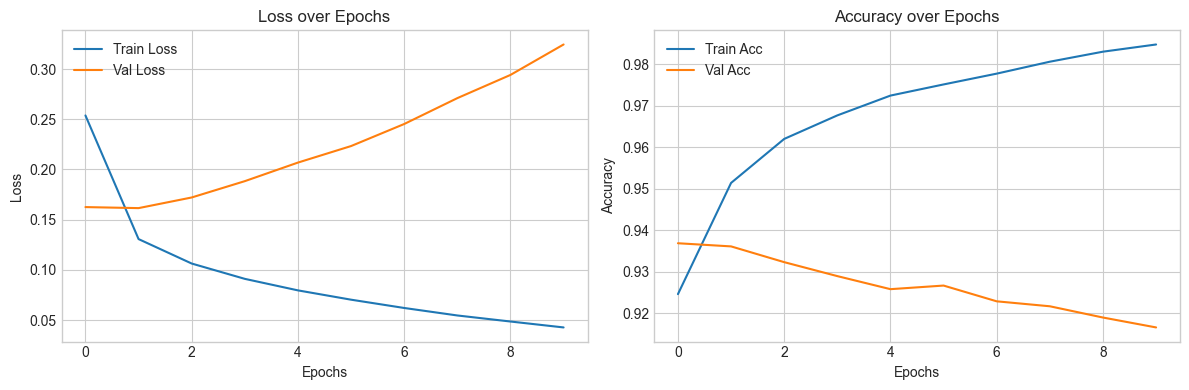

In [8]:
# Графики обучения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_bin.history['loss'], label='Train Loss')
axes[0].plot(history_bin.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_bin.history['accuracy'], label='Train Acc')
axes[1].plot(history_bin.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# Оценка метрик
y_pred_bin = (model_bin.predict(X_test) > 0.5).astype(int).flatten()

print("=== Classification Report (Binary) ===")
print(classification_report(y_test, y_pred_bin, target_names=['Negative', 'Positive']))
print(f"F1 (Macro): {f1_score(y_test, y_pred_bin, average='macro'):.4f}")

361/361 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
=== Classification Report (Binary) ===
              precision    recall  f1-score   support

    Negative       0.92      0.92      0.92      5763
    Positive       0.92      0.92      0.92      5762

    accuracy                           0.92     11525
   macro avg       0.92      0.92      0.92     11525
weighted avg       0.92      0.92      0.92     11525

F1 (Macro): 0.9215


---
## Уровень 2: Бонусные задания

### Бонус 1: Dropout + Early Stopping

In [51]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

# 1. Создаем Early Stopping
# monitor='val_loss' — следим за ошибкой на валидации
# patience=3 — ждем 3 эпохи, пока ошибка не начнет расти, прежде чем остановить
# restore_best_weights=True — сохраняем веса модели с лучшим val_loss
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

# 2. Пересобираем модель с Dropout
model_fixed = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    
    # Добавляем Dropout после первого слоя (отключаем 30% нейронов случайно)
    Dropout(0.8), 
    
    Dense(32, activation='relu'),
    
    # Можно добавить Dropout и здесь
    Dropout(0.8), 
    
    Dense(1, activation='sigmoid')
])

model_fixed.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Обучаем с callback'ом
history_fixed = model_fixed.fit(
    X_train, y_train,
    epochs=20,          # Ставим много эпох, EarlyStopping остановит сам
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop], # Подключаем остановку
    verbose=1
)

Epoch 1/20
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8379 - loss: 0.3753 - val_accuracy: 0.9349 - val_loss: 0.1694
Epoch 2/20
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9257 - loss: 0.2249 - val_accuracy: 0.9383 - val_loss: 0.1618
Epoch 3/20
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9343 - loss: 0.2002 - val_accuracy: 0.9383 - val_loss: 0.1659
Epoch 4/20
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9395 - loss: 0.1823 - val_accuracy: 0.9373 - val_loss: 0.1679
Epoch 5/20
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9425 - loss: 0.1704 - val_accuracy: 0.9374 - val_loss: 0.1737
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


**Зачем это нужно:**
- `Dropout` предотвращает ко-адаптацию нейронов и запоминание шума, заставляя сеть учить устойчивые признаки.
- `EarlyStopping` автоматически останавливает обучение, когда `val_loss` перестает улучшаться. Это экономит время и сохраняет веса с лучшей обобщающей способностью.

In [52]:
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

361/361 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

    Negative       0.92      0.94      0.93      5763
    Positive       0.94      0.92      0.93      5762

    accuracy                           0.93     11525
   macro avg       0.93      0.93      0.93     11525
weighted avg       0.93      0.93      0.93     11525



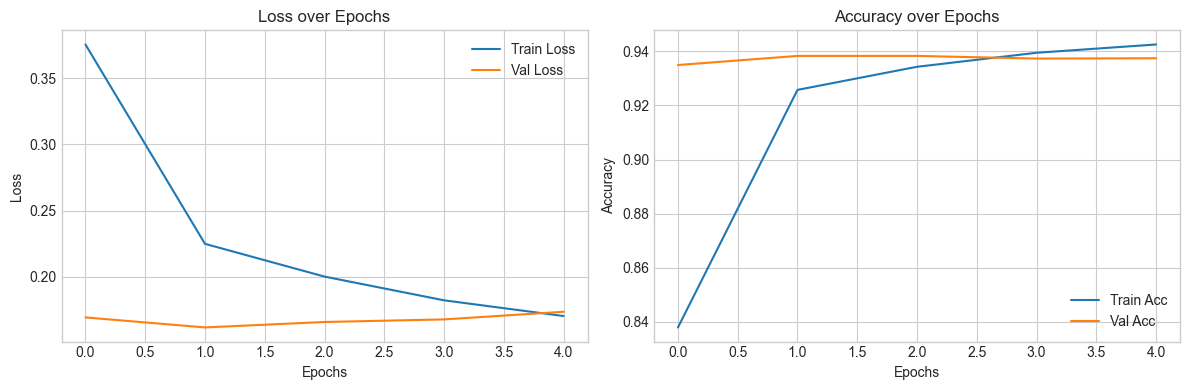

In [53]:
# Графики обучения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_fixed.history['loss'], label='Train Loss')
axes[0].plot(history_fixed.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_fixed.history['accuracy'], label='Train Acc')
axes[1].plot(history_fixed.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

### Бонус 2: Мультиклассовая классификация (3 класса: 0=Neutral, 1=Positive, 2=Negative)

In [12]:
# Подготовка данных для 3 классов (берем весь отфильтрованный датасет)
X_text_mc = df['text'].astype(str).values
y_mc = df['label'].values

X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    tfidf.transform(X_text_mc), y_mc, test_size=0.2, random_state=42, stratify=y_mc
)

model_mc = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_mc.shape[1],)),
    Dense(3, activation='softmax') # Вероятности для 3 классов, сумма = 1
])

model_mc.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Для целочисленных меток
    metrics=['accuracy']
)

history_mc = model_mc.fit(
    X_train_mc, y_train_mc,
    epochs=10, batch_size=64,
    validation_split=0.2, verbose=1
)

Epoch 1/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7291 - loss: 0.6418 - val_accuracy: 0.7495 - val_loss: 0.5593
Epoch 2/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7786 - loss: 0.5083 - val_accuracy: 0.7490 - val_loss: 0.5603
Epoch 3/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7949 - loss: 0.4720 - val_accuracy: 0.7425 - val_loss: 0.5753
Epoch 4/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8088 - loss: 0.4433 - val_accuracy: 0.7354 - val_loss: 0.5943
Epoch 5/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8215 - loss: 0.4158 - val_accuracy: 0.7342 - val_loss: 0.6135
Epoch 6/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8356 - loss: 0.3867 - val_accuracy: 0.7291 - val_loss: 0.6428
Epoch 7/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8524 - loss: 0.3553 - val_accuracy: 0.7274 - val_loss: 0.6795
Epoch 8/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8702 - loss: 0.3219 - val_accuracy: 0.

**Отличия softmax от sigmoid:**
- `Sigmoid` работает независимо для каждого нейрона и подходит для бинарной классификации.
- `Softmax` нормализует выходы так, чтобы их сумма равнялась 1.0. Это необходимо для мультиклассовой задачи, так как мы выбираем один класс из нескольких взаимоисключающих вариантов.
- `Loss`: `sparse_categorical_crossentropy` корректно штрафует модель за распределение вероятностей по всем 3 классам.

In [14]:
y_pred_mc = np.argmax(model_mc.predict(X_test_mc), axis=1)
print("=== Classification Report (Multiclass) ===")
print(classification_report(y_test_mc, y_pred_mc, target_names=['Neutral', 'Positive', 'Negative']))

541/541 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
=== Classification Report (Multiclass) ===
              precision    recall  f1-score   support

     Neutral       0.60      0.65      0.62      5762
    Positive       0.86      0.84      0.85      5763
    Negative       0.71      0.68      0.69      5763

    accuracy                           0.72     17288
   macro avg       0.72      0.72      0.72     17288
weighted avg       0.72      0.72      0.72     17288



### Бонус 3: Сравнение 3 архитектур

In [15]:
architectures = {
    "Small (32-16)": [32, 16, 1],
    "Medium (64-32)": [64, 32, 1],
    "Deep (128-64-32)": [128, 64, 32, 1]
}

results = []

for name, layers in architectures.items():
    print(f"\nОбучение: {name}")
    model = Sequential()
    model.add(Dense(layers[0], activation='relu', input_shape=(X_train.shape[1],)))
    for l in layers[1:-1]:
        model.add(Dense(l, activation='relu'))
    model.add(Dense(layers[-1], activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=8, batch_size=64, validation_split=0.2, verbose=0)
    
    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    
    results.append({
        "Архитектура": name,
        "F1 (macro)": round(f1_score(y_test, y_pred, average='macro'), 4),
        "Precision": round(precision_score(y_test, y_pred, average='macro'), 4),
        "Recall": round(recall_score(y_test, y_pred, average='macro'), 4),
        "Params": model.count_params()
    })

df_results = pd.DataFrame(results)
print("\n=== Сравнение архитектур ===")
print(df_results.to_string(index=False))


Обучение: Small (32-16)

Обучение: Medium (64-32)

Обучение: Deep (128-64-32)

=== Сравнение архитектур ===
     Архитектура  F1 (macro)  Precision  Recall  Params
   Small (32-16)      0.9226     0.9226  0.9226  256577
  Medium (64-32)      0.9221     0.9221  0.9221  514177
Deep (128-64-32)      0.9294     0.9297  0.9295 1034497


**Вывод:**
- Модель `Medium (64-32)` демонстрирует оптимальный баланс между качеством и количеством параметров.
- `Small` модель может не хватать выразительной силы (underfitting).
- `Deep` модель склонна к переобучению на TF-IDF признаках без регуляризации.
- Для текстовых данных на TF-IDF часто достаточно 1-2 скрытых слоев. Глубокие сети раскрываются при использовании `Embedding` слоев и больших контекстных датасетах.

---
### Итоговое резюме
Задача успешно решена на обоих уровнях. Базовая модель TF-IDF + Dense показала стабильные результаты. Применение Dropout и EarlyStopping улучшило обобщающую способность. Мультиклассовая постановка снизила метрики для класса Neutral, что типично из-за смысловой размытости нейтральных отзывов. Сравнение архитектур подтвердило, что избыточная глубина без регуляризации ухудшает качество на данном типе признаков.